# **Actividad 1. Notebook de formulación y simulación de un modelo determinista**

*Axel Ibarra Cruz*
*2253801144*

## **1. Planteamiento del problema**

Se eligio el **Modelo de enfriamiento de Newton discreto**

\begin{equation}
    T_{t+1} = T_t - k(T-t - T_a)
\end{equation}

para simular el enfriamiento de una pizza sacada del horno, donde la temperatura disminuye con forme a la temperatura ambiente, sin aleatoriedad.

Lo que se busca es ver el decaimiento de la temperatura de la pizza con forme la temperatura ambiente, donde vamos a ir variando la temperatura de la pizza, y se podría variar la temperatura ambiental para ver el comportamiento en diferentes situaciones.


## **2. Variables, parámetros y supuestos**

Nuestras variables son:

* $T_t$:= Temperatura de la pizza en el tiempo ($t$).


Nuestros parámetros son:

* $T_a$:= Temperatura ambiente.
* $k$:= Constante de enfriamiento.


Nuestros supuestos son:

* El tiempo transcurre minuto por minuto (intervalos discretos).
* La temperatura ambiente ($T_a$) permance constante durante todo el tiempo.
* La pizza es uniforme, por lo que la temperatura se distribuye uniformemente sobre la misma.
* La pizza sale directamente del horno y se deja sobre una superficie, todo sin alterar la temperatura de la pizza
  (Solo se cuenta la temperatura de la pizza y la ambiente).


## **3. Formulación matemática del modelo**

El model de enfriamiento de Newton dice


\begin{equation}
    T_{t+1} = T_t - k(T-t - T_a)
\end{equation}

donde:

* $T_t$ representa la temperatura de la pizza al salir del horno,
* $T_a$ representa la temperatura ambiente de donde se deja la pizza y
* $k$ es la constante de enfriamiento, es decir, el porcentaje con el que cambia la temperatura.


Este modelo nos dice como cambia la temperatura con forme a la diferencia de las temperaturas y
de las características de la pizza.

El modelo dice cuanto tiempo tardara en ambientarse la pizza bajo los criterios que asignemos.

PPodemos interpretar que para la temperatura $T_{t+1}$ es la temperatura en el siguiente tiempo de la
temperatura $T_t$ con una perdida de temperatura. Esa perdida se da por la constante de enfriamiento
$k$ en la diferencia de las temperaturas de la pizza y del ambiente ($T_a$).

Partimos con las siguientes condiciones iniciales:

* $T_0 = 75^\circ\text{C}$ (temperatura inicial de la pizza).
* $T_a = 22^\circ\text{C}$ (temperatura ambiente).
* $t \in [0, 60]$ minutos.

## **5. Simulación base**

In [22]:
# Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Definimos nuestra función de enfriamiento

def enfriamiento(T0, Ta, k, tiempo):
    lista =[]
    T_actual = T0   # Empezamos con la temperatura inicial de la pizza

    # Ciclo for para ir gaurdando las iteraciones en el tiempo
    for t in range(tiempo+1):
        lista.append({"Tiempo (minutos)": t, "Temperatura (°C)": T_actual})
        T_actual = T_actual - k*(T_actual-Ta)

    df = pd.DataFrame(lista)
    return df

In [24]:
# Ingresamos los datos iniciales

T0 = 75
Ta = 22
k = 0.15
tiempo = 60

df_enfriamiento = enfriamiento(T0, Ta, k, tiempo)   # Llammos a nuestra función

df_enfriamiento  # No usamos .head para poder ver las primeras y las ultimas iteraciones

,Tiempo (minutos),Temperatura (°C)
0,0,75.000000
1,1,67.050000
2,2,60.292500
3,3,54.548625
4,4,49.666331
...,...,...
56,56,22.005912
57,57,22.005025
58,58,22.004271
59,59,22.003631


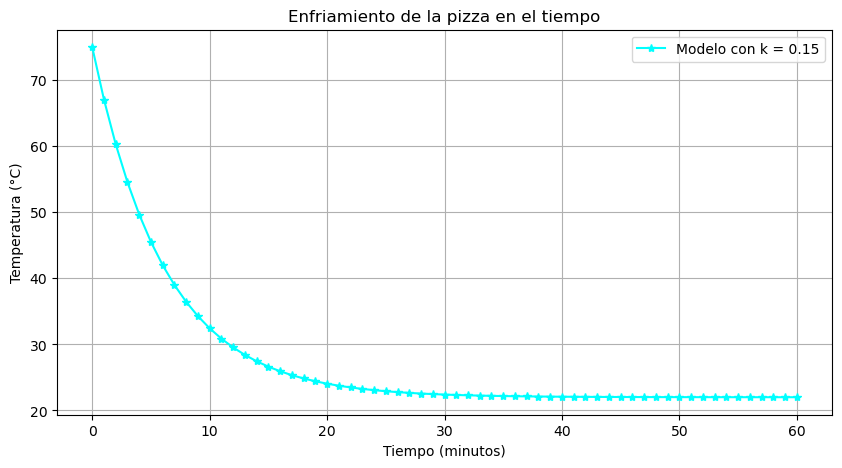

In [26]:
# Modelación de los datos en una gráfica

plt.figure(figsize=(10, 5))

plt.plot(
    df_enfriamiento["Tiempo (minutos)"],
    df_enfriamiento["Temperatura (°C)"],
    label="Modelo con k = 0.15",
    color='cyan',
    marker="*"
)

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Enfriamiento de la pizza en el tiempo")
plt.legend()
plt.grid()

plt.show()

   **Análisis**

Podemos ver que la temperatura de la pizza decae rapidamente en los primeros 10 minutos desde que salio del horno,
esto derivado de la alta diferencia entre ambas temperaturas, lo que hace que pierda esa temperatura en tan poco tiempo.
Al final, podemos ver que, aproximadamente, desde el minuto 30 la temperatura esta demasiado cerca a la del ambiente, por 
lo que podemos decir que desde ese tiempo "iguala" la temperatura ambiente.

## **6. Análisis de sensibilidad**

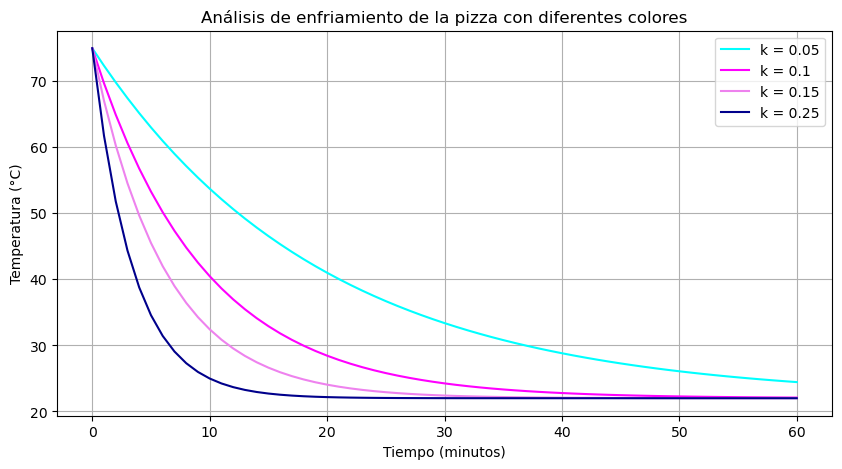

In [53]:
# Agregamos varios valores para la
# constante de enfriamiento

valores_k = [0.05, 0.10, 0.15, 0.25]
colores = ['cyan', 'fuchsia', 'violet', 'darkblue']  # Agregue cambio de colore, me llevo más tiempo de lo que pensé.

# Gráfica de comparación
plt.figure(figsize=(10, 5))

# Usamos zip para iterar sobre k y los colores al mismo tiempo
# La parte del zip la obtuve por IA :(
for k, color in zip(valores_k, colores):
    
    # Usamos nuestra función definida
    df_escenario = enfriamiento(T0, Ta, k, tiempo)

    plt.plot(
        df_escenario["Tiempo (minutos)"],
        df_escenario["Temperatura (°C)"],
        label=f"k = {k}",
        color=color
    )

# Configuraciones finales
plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Análisis de enfriamiento de la pizza con diferentes colores")
plt.legend()
plt.grid()

plt.show()

**Análisis de sensibilidad**

Podemos ver que con un valor de k más pequeño, el decaimiento de la temperatura es más lento, y por lo contrario, una k más alta, representa un enfriamiento más pronunciado.

## **7. Comparación con datos observados**

In [58]:
# Tomemos los siguientes datos observados propuestos.
# Se tomo la temperatura de la pizza cada 10 minutos.

datos_observados = pd.DataFrame({
    "Tiempo (minutos)": [0, 10, 20, 30, 40, 50, 60],
    "Temperatura observada (°C)": [75.0, 44.8, 32.5, 27.1, 23.5, 22.6, 22.1]
})

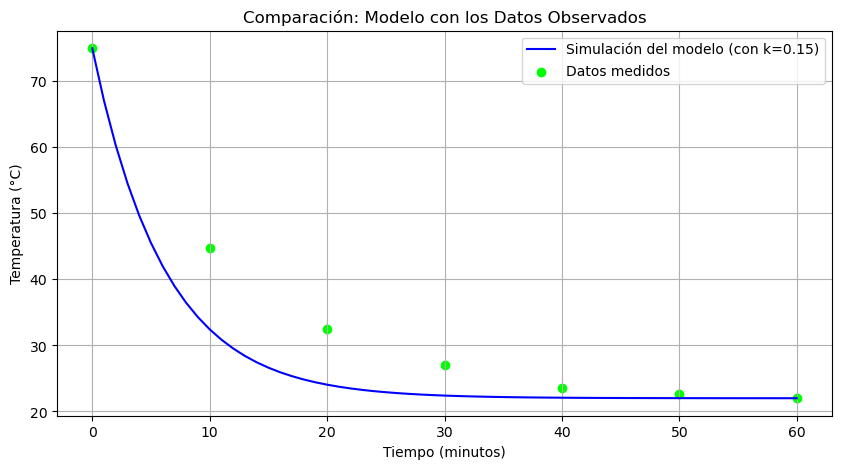

In [62]:
# Hacemos una comparación con los datos obtenidos
# en la sección 5 en el df_base.

plt.figure(figsize=(10, 5))

plt.plot(
    df_enfriamiento["Tiempo (minutos)"], 
    df_enfriamiento["Temperatura (°C)"], 
    label="Simulación del modelo (con k=0.15)", 
    color="blue"
)

# Graficamos los puntos sueltos de los datos observados
plt.scatter(
    datos_observados["Tiempo (minutos)"], 
    datos_observados["Temperatura observada (°C)"], 
    label="Datos medidos", 
    color="lime"#,
    #zorder=5 # Esto asegura que los puntos se dibujen por encima de la línea*** 
)

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación: Modelo con los Datos Observados")
plt.legend()
plt.grid()

plt.show()

# ***(IA)

Como podemos ver, nuestra k inicial no es perfecta, ya que los valores estan muy alejados de la gráfica, por lo que podemos
mejorar nuestros datos.

## **8. Ajuste simple de un parámetro**

Primero debemos ver las diferencias entre las temperaturas, para poder encontrar el de menor error, así que poemos aplicar
valor absoluto o elevar al cuadrado, esto para evitar errores y cancelaciones a la hora de la comparación.

*Nota*: Tenemos un pequeño problema con las dimensiones de los dataframe!!

In [65]:
# Hacemos un filtrado del dt_enfriamiento para igualar
# las dimesniones de los dataframe.

df_escenario = df_enfriamiento[ df_enfriamiento["Tiempo (minutos)"].isin([0, 10, 20, 30, 40, 50, 60])]

df_escenario

,Tiempo (minutos),Temperatura (°C)
0,0,75.000000
10,10,32.434343
20,20,24.054255
30,30,22.404430
40,40,22.079622
50,50,22.015676
60,60,22.003086


In [80]:
# Tiempos de mediciones reales
tiempos_observados = [0, 10, 20, 30, 40, 50, 60]

# Hacemos el dataframe de datos_observados
datos_observados = pd.DataFrame({
    "Tiempo (minutos)": tiempos_observados,
    "Temperatura observada (°C)": [75, 35, 25, 23, 22.5, 22.2, 22.1]
})

# Valores de k para hacer la prueba
valores_prueba = [0.10, 0.12, 0.14, 0.15, 0.16, 0.18, 0.20]

for k_prueba in valores_prueba:
    df_simulacion = enfriamiento(T0, Ta, k_prueba, tiempo)
    
    # Tomamos los tiempos obsservados
    df_filtrado = df_simulacion[df_simulacion["Tiempo (minutos)"].isin(tiempos_observados)]

    temp_simulada = df_filtrado["Temperatura (°C)"].values
    temp_obs = datos_observados["Temperatura observada (°C)"].values
    
    # Aquí hacemos el valor absoluto
    error_total = np.abs(temp_simulada - temp_obs).sum()
    
    print(f"Para k = {k_prueba}, el error total es: {error_total}")  # No me acuerdo como hacer el redonde, no sé donde iba :(

Para k = 0.1, el error total es: 10.53154674317518
Para k = 0.12, el error total es: 3.3838721356223473
Para k = 0.14, el error total es: 2.73947641024019
Para k = 0.15, el error total es: 4.808587560441929
Para k = 0.16, el error total es: 6.565587716755978
Para k = 0.18, el error total es: 9.3544838955745
Para k = 0.2, el error total es: 11.424626541357775


In [113]:
# Aquí podemos calcular el mínimo
tiempos_observados = [0, 10, 20, 30, 40, 50, 60]
valores_prueba = [0.10, 0.12, 0.14, 0.15, 0.16, 0.18, 0.20]

# Variables para guardar al mínimo
mejor_k = None   # Guardamos para ir seleccionando
menor_error = float('inf') # Iniciamos con un error infinitamente grande

for k_prueba in valores_prueba:
    df_simulacion = enfriamiento(T0, Ta, k_prueba, tiempo_total)
    df_filtrado = df_simulacion[df_simulacion["Tiempo (minutos)"].isin(tiempos_observados)]
    
    temp_simulada = df_filtrado["Temperatura (°C)"].values
    temp_observada = datos_observados["Temperatura observada (°C)"].values
    
    error_total = np.abs(temp_simulada - temp_obs).sum()
    
    # Si este error es el más bajo que hemos visto, actualizamos al mínimo
    if error_total < menor_error:
        menor_error = error_total
        mejor_k = k_prueba

print(f"El mejor parámetro encontrado es k = {mejor_k} con un error total de {menor_error}")

El mejor parámetro encontrado es k = 0.14 con un error total de 2.73947641024019


## **9. Gráfica del mejor modelo**

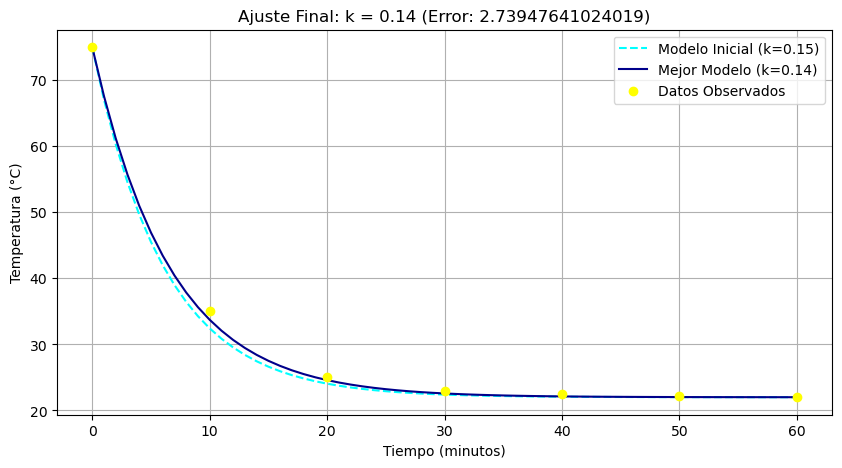

In [117]:
# Simulamos el mejor modelo usando el error total mínimo
df_mejor = enfriamiento(T0, Ta, mejor_k, tiempo_total)

plt.figure(figsize=(10, 5))

# Linea dato inicial (k = 0.15)
plt.plot(df_enfriamiento["Tiempo (minutos)"], df_enfriamiento["Temperatura (°C)"], 
         label="Modelo Inicial (k=0.15)", color="cyan", linestyle="--")

# Ajustamos el modelo
plt.plot(df_mejor["Tiempo (minutos)"], df_mejor["Temperatura (°C)"], 
         label=f"Mejor Modelo (k={mejor_k})", color="darkblue")

# Datos observados reales
plt.scatter(
    datos_observados["Tiempo (minutos)"], 
    datos_observados["Temperatura observada (°C)"],
    label="Datos Observados", color="yellow",
    zorder=5 # Que sireve para poner sobre la linea#
) 

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title(f"Ajuste Final: k = {mejor_k} (Error: {menor_error})")
plt.legend()
plt.grid()

plt.show()

## **10. Extensión: entrenamiento y prueba**

In [123]:
# Primero, tomemos algunos datos 
tiempos_train = [0, 10, 20, 30]
tiempos_test = [40, 50, 60]

for k_prueba in valores_prueba:
    df_simulacion = enfriamiento(T0, Ta, k_prueba, tiempo)
    
    # Filtramos la simulación para los tiempos de entrenamiento
    df_filtrado = df_simulacion[df_simulacion["Tiempo (minutos)"].isin(tiempos_train)]
    temp_simulada = df_filtrado["Temperatura (°C)"].values
    
    # Debemos hacer que coincidad los datos filtrados
    datos_train = datos_observados[datos_observados["Tiempo (minutos)"].isin(tiempos_train)]
    temp_obs = datos_train["Temperatura observada (°C)"].values
    
    error_total = np.abs(temp_simulada - temp_obs).sum()
    
    print(f"Para k = {k_prueba}, el error de entrenamiento es: {error_total}")

Para k = 0.1, el error de entrenamiento es: 10.170251407186644
Para k = 0.12, el error de entrenamiento es: 3.016249419025687
Para k = 0.14, el error de entrenamiento es: 2.100953904322182
Para k = 0.15, el error de entrenamiento es: 4.106971163938599
Para k = 0.16, el error de entrenamiento es: 5.825375372513761
Para k = 0.18, el error de entrenamiento es: 8.57635725609676
Para k = 0.2, el error de entrenamiento es: 10.632509113276239


**NOTA**: El apartado 10 no logre entenderlo por completo, al parecer estuve reciclando el código
y no pude realizar los cambios que pedía este apartado. Me gustaría saber mis errores, intente
utilizar IA, pero preferi ya no seguir, ya que lo que me arrojaba ya eran cosas que no entendía
completamente, algunas cosas en apartados anteriores si llegue a comprenderlos, pero ya para el
último, la mayoría de mi código era obtenido de la IA.

## **11. Conclusiones**

Lo principal que aprendí de este modelo es ver que hay demasaidas variables que tomar en cuenta para una simulación tan "simple" como el enfriamiento
de una pizza, donde dejamos de lado varias cuestiones y que logra simplificar los calculos demasiado.

Tomando en cuenta los parámetros que utilizamos, yo digo que la constante de enfriamiento $k$ es la que tienen un mayor efecto en el modelo, aunque la diferencia de temperaturas también impacta, estaríamos tomando dos cuestiones y ya no sería tan justo en ese sentido.

Este modelo tiene un buen punto de vista, ya que si modela muy bien estos datos, se acerca bastante a pesar de ser un modelo discreto, puede cumplir con las espectativas del problema.

Derivado de lo anterior, la falta de variables que interactuan con el fenómeno no son todas, es decir, se deja fuera muchas cosas que pueden alterar estas mediciones, por lo que sería un caso "ideal".

Si pudieramos saber el material de la superficie, la misma superficie de la pizza, si esta en constante cambio (Se la comen o la toca), si esta cerca de una ventana o un ventilador o algún objeto que dispare el decaimiento de la tem